(example_explore_eos_with_dimensionality_reduction)=

# Exploring EoS with dimensionality reduction techniques

### The first step before applying any harmonization technique is to understand and characterize our data.
### Usually, we deal with high dimensional data. In order to reduce the dimensions of the problem and see how much target and Effect of Site (EoS) information there is in our data.
### Let's explore how simulated data looks like using different dimensionality reduction methods.

For this we will use the function `plot_2d_projection` of `uniharmony`, that allows us to pass our data and automatically generate a scatter plot.

In [1]:
# Imports
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import FastICA

from uniharmony import make_multisite_classification, verbosity
from uniharmony.plot import plot_2d_projection


sns.set_theme(style="whitegrid")
verbosity("warning")

### Let's simulate data with only Effects of Site (EoS) or only real signal, and see how tSNE groups the target and Eos.

2026-04-30 09:29:46 [warning  ] signal_strength is 0. Adding a delta (1e-6) to signal_strength to avoid degenerate data.


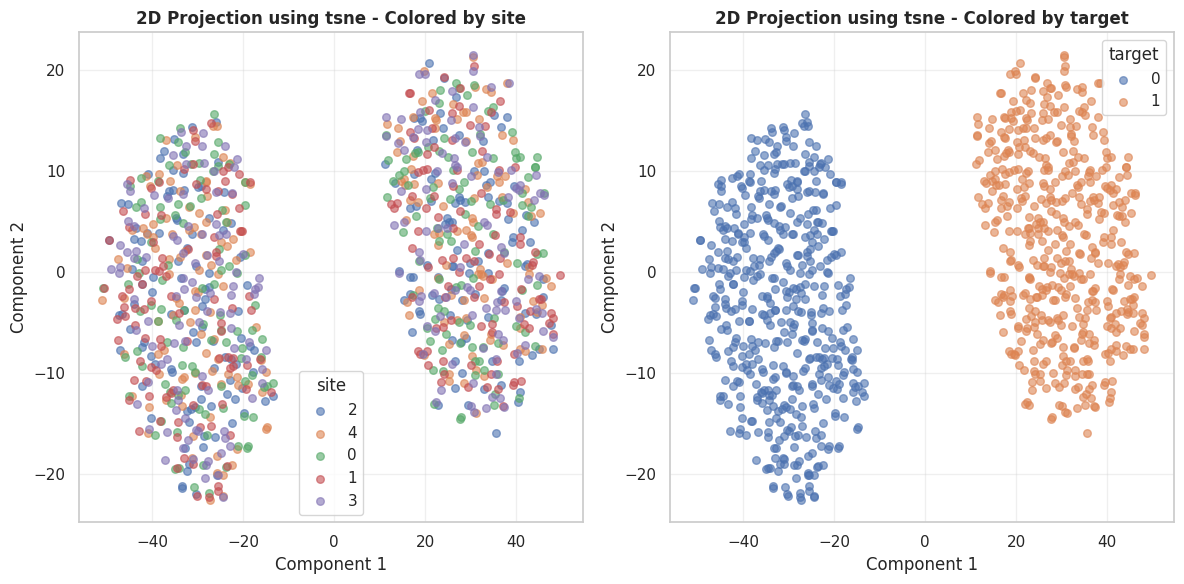

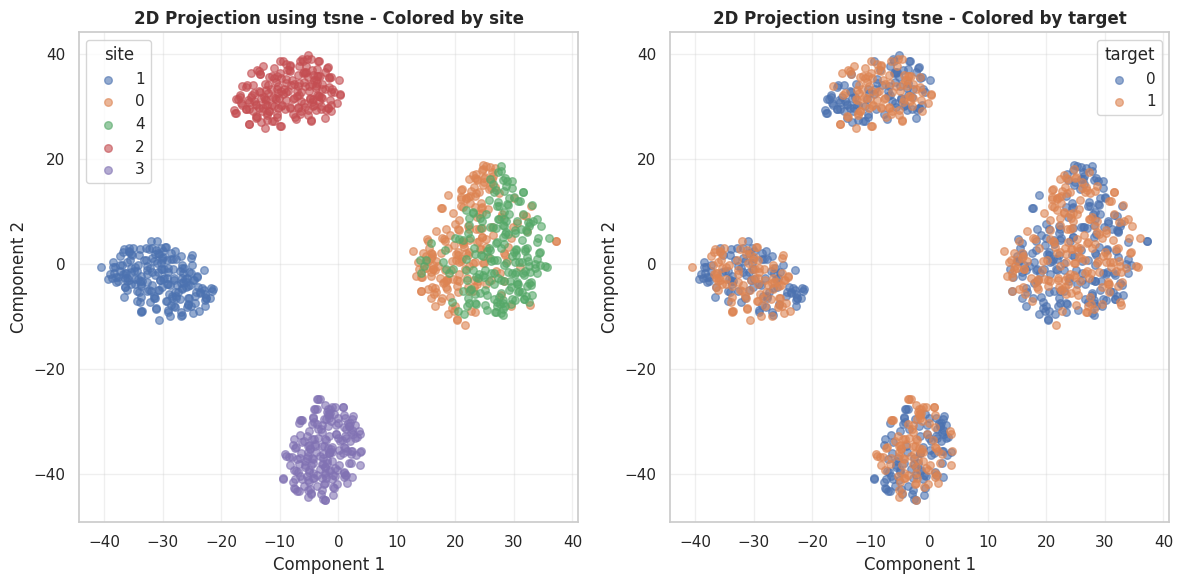

In [2]:
X, y, sites = make_multisite_classification(n_sites=5, signal_strength=10, site_effect_strength=0)
# Using the function as default. The function will use t-SNE as default dimensionality reductor.
plot_2d_projection(X, sites, y)

X, y, sites = make_multisite_classification(n_sites=5, signal_strength=0, site_effect_strength=10, random_state=23)
plot_2d_projection(X, sites, y)
plt.show()

In the first plot, we see that classes are perfectly separated and the sites are all mixed in the clusters. 
This is because tSNE used the target information to get the clusters, as there was no EoS information.

In the second plot, exactly the opposite happened, tSNE clustered the sites almost perfectly.

## Let's try now another dimensionality reduction method.

2026-04-30 09:29:50 [warning  ] signal_strength is 0. Adding a delta (1e-6) to signal_strength to avoid degenerate data.


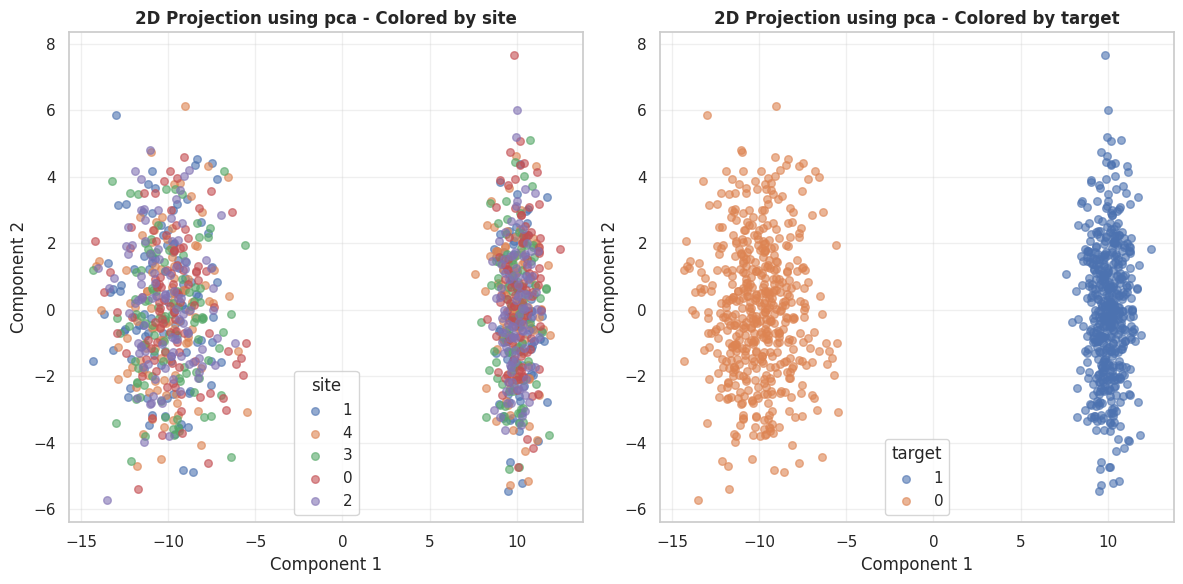

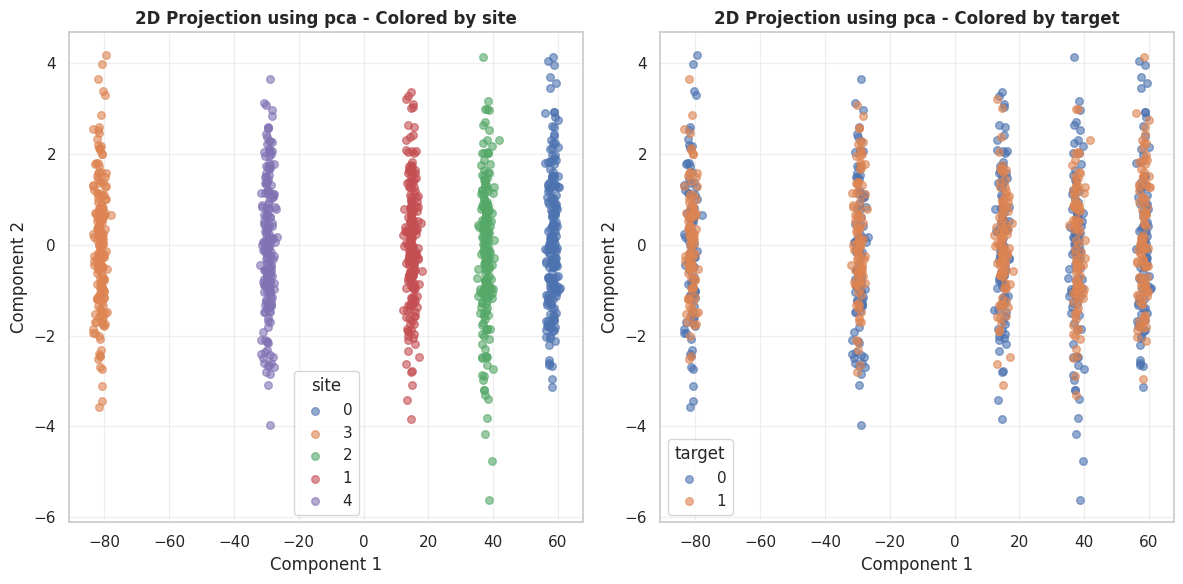

In [3]:
X, y, sites = make_multisite_classification(n_classes=2, n_sites=5, n_features=1200, signal_strength=10, site_effect_strength=0)
# We can also pass the method as string. Only a few methods are available to pass as string in "method"
plot_2d_projection(X, sites, y, method="pca")


X, y, sites = make_multisite_classification(n_classes=2, n_sites=5, n_features=120, signal_strength=0, site_effect_strength=10)
fig, axes = plot_2d_projection(X, sites, y, method="pca")
plt.show()

2026-04-30 09:29:51 [warning  ] signal_strength is 0. Adding a delta (1e-6) to signal_strength to avoid degenerate data.


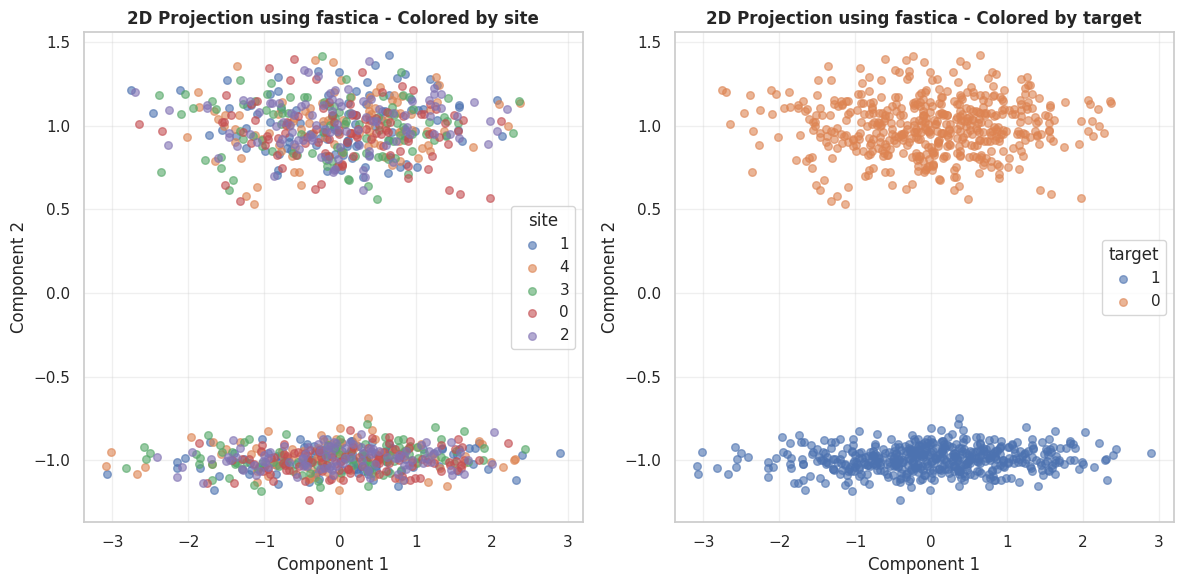

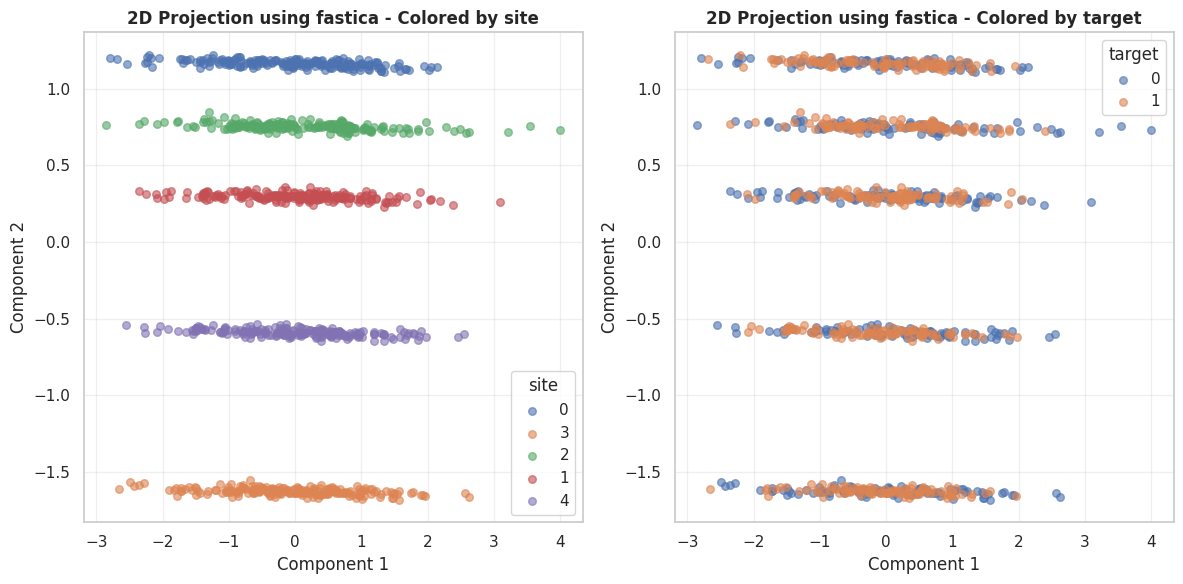

In [4]:
dim_reductor = FastICA(n_components=2)
X, y, sites = make_multisite_classification(n_classes=2, n_sites=5, n_features=1200, signal_strength=10, site_effect_strength=0)
# We can also pass directly an instance of the dimensionality reductor that we want to use.
plot_2d_projection(X, sites, y, dim_reductor=dim_reductor)


X, y, sites = make_multisite_classification(n_classes=2, n_sites=5, n_features=120, signal_strength=0, site_effect_strength=10)
fig, axes = plot_2d_projection(X, sites, y, dim_reductor=dim_reductor)
plt.show()

We found similar behavior using PCA os FastICA, but different clusters were generated.